In [26]:
!pip install numpy pandas matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.1 MB/s  0:00:00
Using cached pillow-12.1.1-cp312-cp312-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [27]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

In [10]:
def heat_fdm(initial, left_bc, right_bc, L=1, T=1, c=1):
    """
    Finite difference solver for the heat equation.

    initial : list
        values of u(x_i,0)

    left_bc : list
        boundary values at x=0 for each time step

    right_bc : list
        boundary values at x=L for each time step
    
    L = length of rod

    T = time to solve for

    c = diffusion constant
    """

    n = len(initial) - 1
    m = len(left_bc) - 1

    h = L / n
    k = T / m

    s = c**2 * k / h**2

    # grid
    x = np.linspace(0, L, n+1)
    t = np.linspace(0, T, m+1)

    # solution array
    u = np.zeros((m+1, n+1))

    # initial condition
    u[0, :] = initial

    # boundary conditions
    for j in range(m+1):
        u[j, 0] = left_bc[j]
        u[j, -1] = right_bc[j]

    # finite difference iteration
    # note: runtime O(nm)
    for j in range(m):
        for i in range(1, n):
            u[j+1, i] = u[j, i] + s * (u[j, i+1] - 2*u[j, i] + u[j, i-1])

    # return grid table
    grid = pd.DataFrame(u, columns=[f"x{i:.2f}" for i in x])
    grid.insert(0, "t", t)

    return grid

In [15]:
def calculate_stability(h, k, c):
    """
    Calculate the stability of the finite difference method.

    h = step size in space

    k = step size in time

    c = diffusion constant
    """
    return c**2 * k / h**2

Dirichlet Boundary Conditions: random initial temperatures

In [ ]:
initial = [random.randint(-100, 100) for _ in range(10)]
left_bc = [0, 0, 0, 0, 0, 0, 0]
right_bc = [0, 0, 0, 0, 0, 0, 0]

print("Inital Condition:", initial)
ans = heat_fdm(initial, left_bc, right_bc)

print("Solution:")
print(ans)

stability = calculate_stability(len(initial), len(right_bc), 1)
if stability > 0.5:
    print("Stability:", stability)
    print("The method is unstable.")
else:
    print("Stability:", stability)
    print("The method is stable.")


Inital Condition: [73, -16, -13, -90, -34, 20, -66, -77, -47, 64]
Solution:
          t  x0.00         x0.11         x0.22         x0.33         x0.44  \
0  0.000000    0.0 -1.600000e+01 -1.300000e+01 -9.000000e+01 -3.400000e+01   
1  0.166667    0.0  2.405000e+02 -1.093000e+03  1.705500e+03 -6.100000e+01   
2  0.333333    0.0 -2.100850e+04  5.468900e+04 -5.992200e+04 -6.347500e+02   
3  0.500000    0.0  1.284522e+06 -2.514476e+06  2.287704e+06  2.530888e+04   
4  0.666667    0.0 -6.734301e+07  1.136014e+08 -9.308407e+07  9.352106e+05   
5  0.833333    0.0  3.284538e+09 -5.119403e+09  3.966430e+09 -1.529727e+08   
6  1.000000    0.0 -1.545099e+11  2.309925e+11 -1.743043e+11  1.205329e+10   

          x0.56         x0.67         x0.78         x0.89  x1.00  
0  2.000000e+01 -6.600000e+01 -7.700000e+01 -4.700000e+01    0.0  
1 -1.870000e+03  9.465000e+02  4.765000e+02  1.825000e+02    0.0  
2  6.057425e+04 -4.342125e+04  2.852500e+03  1.687750e+03    0.0  
3 -2.169686e+06  1.985214e+06 -

Random Boundary Conditions

In [17]:
import random

initial = [random.randint(-100, 100) for _ in range(10)]
left_bc = [random.randint(-100, 100) for _ in range(10)]
right_bc = [random.randint(-100, 100) for _ in range(10)]

print("Inital Condition:", initial)
ans = heat_fdm(initial, left_bc, right_bc)

print("Solution:")
print(ans)

stability = calculate_stability(len(initial), len(right_bc), 1)
if stability > 0.5:
    print("Stability:", stability)
    print("The method is unstable.")
else:
    print("Stability:", stability)
    print("The method is stable.")


Inital Condition: [-84, 54, -58, 23, 24, 95, -38, 10, 74, 82]
Solution:
          t  x0.00         x0.11         x0.22         x0.33         x0.44  \
0  0.000000  -77.0  5.400000e+01 -5.800000e+01  2.300000e+01  2.400000e+01   
1  0.111111  -51.0 -2.133000e+03  1.679000e+03 -6.970000e+02  6.540000e+02   
2  0.222222  -98.0  5.091300e+04 -5.401300e+04  3.284600e+04 -3.306000e+04   
3  0.333333  -60.0 -1.352520e+06  1.672052e+06 -1.342039e+06  1.305852e+06   
4  0.444444  -74.0  3.804077e+07 -5.267592e+07  4.961580e+07 -4.792313e+07   
5  0.555556   38.0 -1.120777e+09  1.684400e+09 -1.748860e+09  1.689284e+09   
6  0.666667   87.0  3.421281e+10 -5.446153e+10  6.009377e+10 -5.827207e+10   
7  0.777778  -67.0 -1.071771e+12  1.774605e+12 -2.036197e+12  1.986811e+12   
8  0.888889   74.0  3.419156e+13 -5.814000e+13  6.846809e+13 -6.732182e+13   
9  1.000000    7.0 -1.104517e+15  1.912317e+15 -2.293114e+15  2.273891e+15   

          x0.56         x0.67         x0.78         x0.89  x1.00  
0 

In [19]:
import math

def sample_function(f, L, num_points):
    """Sample the function f at equal intervals over [0, L] (inclusive)."""
    if num_points < 2:
        raise ValueError("num_points must be 2 or more")
    step = L / (num_points - 1)
    samples = [f(step * i) for i in range(num_points)]
    return samples


## Analytic Solution of the Heat Equation

We solve the 1-D heat equation

$$
u_t = c^2 u_{xx}, \qquad 0<x<1,\; t>0
$$

with boundary conditions

$$
u(0,t)=0, \qquad u(1,t)=0
$$

and initial condition

$$
u(x,0)=x
$$

---

### Separation of Variables

Assume a solution of the form

$$
u(x,t)=X(x)T(t)
$$

Substituting into the PDE gives

$$
XT' = c^2 X''T
$$

Dividing by \(XT\):

$$
\frac{T'}{c^2T} = \frac{X''}{X} = -\lambda
$$

---

### Spatial Eigenvalue Problem

$$
X''+\lambda X=0
$$

with boundary conditions

$$
X(0)=0,\qquad X(1)=0
$$

The eigenvalues and eigenfunctions are

$$
\lambda_n=(n\pi)^2
$$

$$
X_n(x)=\sin(n\pi x)
$$

---

### Time Solution

$$
T_n(t)=e^{-c^2(n\pi)^2 t}
$$

For \(c=1\),

$$
T_n(t)=e^{-(n\pi)^2 t}
$$

---

### General Solution

$$
u(x,t)=\sum_{n=1}^{\infty} b_n \sin(n\pi x)e^{-(n\pi)^2 t}
$$

---

### Fourier Coefficients

Using the initial condition \(u(x,0)=x\),

$$
x=\sum_{n=1}^{\infty} b_n \sin(n\pi x)
$$

The coefficients are

$$
b_n = 2\int_0^1 x\sin(n\pi x)\,dx
$$

which evaluates to

$$
b_n=\frac{2(-1)^{n+1}}{n\pi}
$$

---

### Final Analytic Solution

$$
u(x,t)=
\sum_{n=1}^{\infty}
\frac{2(-1)^{n+1}}{n\pi}
\sin(n\pi x)
e^{-(n\pi)^2 t}
$$


In [ ]:
def analytic_solution(x, t):
    terms = []
    for n in range(1, 100):
        coefficient = 2 * ((-1) ** (n + 1)) / (n * math.pi)
        sine_term = math.sin(n * math.pi * x)
        exponential_term = math.exp(- (n * math.pi) ** 2 * t)
        terms.append(coefficient * sine_term * exponential_term)
    return sum(terms)

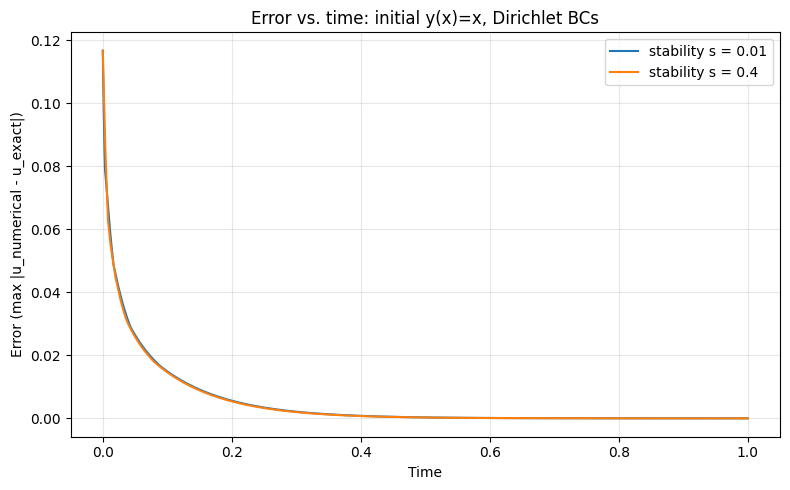

In [33]:
import matplotlib.pyplot as plt

# Parameters: initial condition y(x) = x, Dirichlet BCs u(0,t)=0, u(1,t)=1
L = 1.0
T = 1.0
c = 1.0
n = 10  # number of space intervals (n+1 points)

# Initial condition via sample_function: y(x) = x
initial = sample_function(lambda x: math.sin(x), L, n + 1)

# Dirichlet boundary conditions (fixed endpoints for all time)
# u(0, t) = 0, u(L, t) = L = 1
stability_values = [0.01, 0.4]

# For s = c^2 * k / h^2 with h = L/n, k = T/m  =>  s = n^2/m  =>  m = n^2/s
m_per_s = [max(2, int(n**2 / s)) for s in stability_values]

plt.figure(figsize=(8, 5))
for s, m in zip(stability_values, m_per_s):
    left_bc = [0.0] * (m + 1)
    right_bc = [L] * (m + 1)  # u(L,t) = L = 1
    grid = heat_fdm(initial, left_bc, right_bc, L=L, T=T, c=c)
    t_vals = grid["t"].values
    # Error at each time: max over x of |u(x,t) - x|
    errors = []
    for j in range(len(t_vals)):
        u_row = grid.drop(columns="t").iloc[j].values
        err = np.max(np.abs(u_row - x_exact))
        errors.append(err)
    plt.plot(t_vals, errors, label=f"stability s = {s}")

plt.xlabel("Time")
plt.ylabel("Error (max |u_numerical - u_exact|)")
plt.title("Error vs. time: initial y(x)=x, Dirichlet BCs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
